### RaschPy global MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Global(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:476: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_97320/2630398501.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': [],
 'strongly_connected': False}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=999` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data.

In [4]:
sim = rp.MFRM_Sim_Global(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5, missing=0, seed=999)
sim.responses.to_csv('mfrm_global_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it (for a single file with a (Rater, Person) MultiIndex — see `loadup_mfrm_xlsx_tabs()`/`loadup_mfrm_multiple()` for one-sheet-per-rater or one-file-per-rater layouts). Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_global_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     3.0     3.0     3.0     3.0     0.0     3.0     4.0   
        Person_2     0.0     1.0     3.0     1.0     1.0     2.0     1.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     4.0     3.0      3.0      2.0      3.0  
        Person_2     3.0     3.0      1.0      2.0      1.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the global rater parameterisation (a single scalar severity per rater). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_global()

CPU times: user 2.59 ms, sys: 260 μs, total: 2.85 ms
Wall time: 2.69 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items.head(2)

Item_1    0.910631
Item_2    0.341321
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


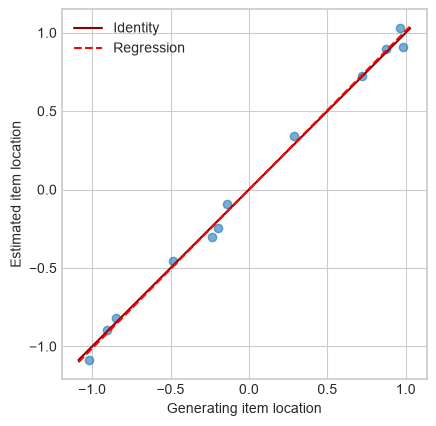

item location Pearson correlation:              0.998
item location SD ratio (estimated / generating): 1.015
item location regression coefficient:            1.013
item location RMSE:                              0.047


In [12]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item location', 'my_mfrm_global_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
mfrm.item_stats_df_global(full=True)
mfrm.item_stats_global.to_csv('mfrm_global_item_stats.csv')

CPU times: user 3 s, sys: 138 ms, total: 3.14 s
Wall time: 3.14 s


Check the item statistics table

In [14]:
mfrm.item_stats_global

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,0.911,0.043,0.830,0.994,1600,0.438,0.984,-0.442,0.958,-1.202,0.652,0.655
Item_2,0.341,0.040,0.261,0.419,1600,0.495,0.976,-0.664,0.983,-0.484,0.654,0.645
Item_3,-0.458,0.042,-0.545,-0.379,1600,0.567,1.004,0.134,1.000,0.024,0.633,0.628
Item_4,0.726,0.044,0.642,0.812,1600,0.459,0.963,-1.060,0.963,-1.033,0.665,0.652
Item_5,1.028,0.048,0.930,1.126,1600,0.428,0.977,-0.652,0.993,-0.177,0.658,0.656
Item_6,-0.091,0.044,-0.171,-0.001,1600,0.537,0.976,-0.682,0.981,-0.531,0.639,0.636
Item_7,-0.245,0.044,-0.326,-0.159,1600,0.546,1.057,1.606,1.054,1.512,0.641,0.632
Item_8,-1.087,0.050,-1.192,-0.984,1600,0.614,0.936,-1.846,0.942,-1.667,0.646,0.616
Item_9,-0.819,0.045,-0.914,-0.744,1600,0.596,0.947,-1.502,0.955,-1.266,0.622,0.621
Item_10,-0.304,0.044,-0.387,-0.219,1600,0.552,0.939,-1.746,0.930,-2.017,0.641,0.631


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
mfrm.threshold_stats_df_global(full=True)
mfrm.threshold_stats_global.to_csv('mfrm_global_threshold_stats.csv')

CPU times: user 95.9 ms, sys: 1.97 ms, total: 97.9 ms
Wall time: 97.9 ms


Check the threshold statistics table

In [16]:
mfrm.threshold_stats_global

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-4.262,0.080,-4.359,-4.060,0.959,-1.213,0.986,-0.181,1.036,0.379,0.361
Threshold 2,-1.531,0.039,-1.605,-1.451,0.986,-1.175,0.983,-0.866,1.033,0.650,0.631
Threshold 3,-1.163,0.036,-1.228,-1.086,0.997,-0.243,0.991,-0.417,1.007,0.846,0.834
Threshold 4,2.386,0.044,2.293,2.463,0.981,-1.399,0.988,-0.431,1.020,0.759,0.747
Threshold 5,4.571,0.084,4.352,4.671,0.919,-1.584,0.922,-0.747,1.043,0.203,0.215


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

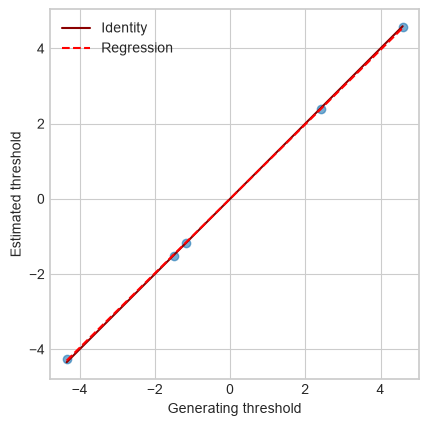

threshold Pearson correlation:              1.0
threshold SD ratio (estimated / generating): 0.99
threshold regression coefficient:            0.99
threshold RMSE:                              0.044


In [17]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_global_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [18]:
%%time
mfrm.rater_stats_df_global()
mfrm.rater_stats_global.to_csv('mfrm_global_rater_stats.csv')

CPU times: user 41.4 ms, sys: 1.58 ms, total: 42.9 ms
Wall time: 42.2 ms


Check the rater statistics table

In [19]:
mfrm.rater_stats_global

,Estimate,SE,Count,Infit MS,Outfit MS
Rater_1,1.302,0.039,2400,0.954,0.938
Rater_2,0.143,0.034,2400,1.000,1.009
Rater_3,-0.214,0.034,2400,0.996,1.004
Rater_4,0.467,0.033,2400,0.981,0.977
Rater_5,-0.742,0.036,2400,1.018,1.016
Rater_6,-0.326,0.034,2400,0.965,0.956
Rater_7,-0.369,0.038,2400,0.964,0.959
Rater_8,-0.260,0.034,2400,0.963,0.960


And the same recovery check for rater severities, against `mfrm.generating.facet_effects`:

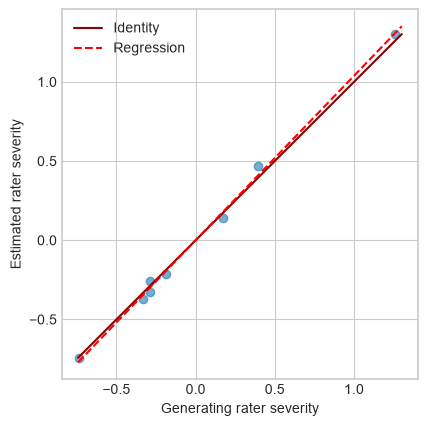

rater severity Pearson correlation:              0.998
rater severity SD ratio (estimated / generating): 1.04
rater severity regression coefficient:            1.038
rater severity RMSE:                              0.04


In [20]:
recovery_plot(mfrm.generating.facet_effects, mfrm.raters_global, 'rater severity', 'my_mfrm_global_rater_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [21]:
%%time
mfrm.person_stats_df_global(full=True)
mfrm.person_stats_global.to_csv('mfrm_global_person_stats.csv')

CPU times: user 14.3 ms, sys: 813 μs, total: 15.1 ms
Wall time: 15.1 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [22]:
mfrm.person_stats_global.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,1.388,0.171,0.178,309,480,0.644,1.082,1.024,0.543,0.196
Person_2,-0.687,0.140,0.142,225,480,0.469,1.026,0.999,0.231,0.048
Person_3,-2.957,0.149,0.138,105,480,0.219,0.859,0.858,-0.962,-0.958
Person_4,-0.030,0.152,0.156,256,480,0.533,1.048,1.098,0.356,0.617
Person_5,0.758,0.166,0.155,287,480,0.598,0.875,0.881,-0.712,-0.648
Person_6,-0.607,0.141,0.151,229,480,0.477,1.133,1.118,0.952,0.774
Person_7,-0.627,0.141,0.144,228,480,0.475,1.041,1.020,0.332,0.181
Person_8,-1.159,0.136,0.138,200,480,0.417,1.031,1.009,0.277,0.111
Person_9,0.954,0.168,0.182,294,480,0.612,1.163,1.209,0.970,1.178
Person_10,-1.772,0.134,0.147,166,480,0.346,1.205,1.217,1.505,1.524


And the same recovery check for person locations, against `mfrm.generating.persons`:

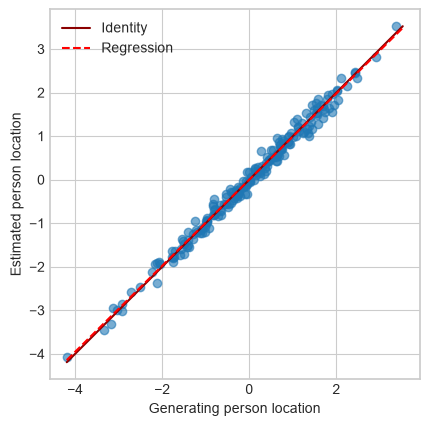

person location Pearson correlation:              0.994
person location SD ratio (estimated / generating): 0.994
person location regression coefficient:            0.989
person location RMSE:                              0.141


In [23]:
recovery_plot(mfrm.generating.persons, mfrm.persons_global, 'person location', 'my_mfrm_global_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [24]:
%%time
mfrm.test_stats_df_global()
mfrm.test_stats_global.to_csv('mfrm_global_test_stats.csv')

CPU times: user 2.79 ms, sys: 599 μs, total: 3.39 ms
Wall time: 3.35 ms


Check the test statistics table

In [25]:
mfrm.test_stats_global

,Items,Persons
Mean,0.000,0.001
SD,0.760,1.324
Separation ratio,17.100,8.598
Strata,23.133,11.798
Reliability,0.997,0.987


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [26]:
%%time
mfrm.item_res_corr_analysis_global()
mfrm.item_residual_correlations_global.to_csv('mfrm_global_item_residual_correlations.csv')
mfrm.item_loadings_global.to_csv('mfrm_global_item_loadings.csv')

CPU times: user 8.87 ms, sys: 2.79 ms, total: 11.7 ms
Wall time: 16 ms


View the table of pairwise item standard residual correlations

In [27]:
round(mfrm.item_residual_correlations_global, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,-0.044,-0.017,-0.042,-0.029,0.004,0.004,-0.019,0.010,-0.033,-0.003,-0.026
Item_2,-0.044,1.000,0.030,-0.013,-0.027,0.012,-0.019,0.007,-0.028,-0.019,-0.033,-0.035
Item_3,-0.017,0.030,1.000,-0.030,-0.003,-0.005,0.004,0.025,-0.013,-0.016,0.028,-0.025
Item_4,-0.042,-0.013,-0.030,1.000,-0.038,-0.039,-0.024,-0.048,-0.003,-0.029,-0.030,-0.029
Item_5,-0.029,-0.027,-0.003,-0.038,1.000,-0.007,0.009,-0.025,-0.042,-0.049,-0.023,-0.003
Item_6,0.004,0.012,-0.005,-0.039,-0.007,1.000,-0.035,0.004,-0.022,-0.014,-0.017,-0.001
Item_7,0.004,-0.019,0.004,-0.024,0.009,-0.035,1.000,-0.027,-0.034,0.014,0.016,-0.023
Item_8,-0.019,0.007,0.025,-0.048,-0.025,0.004,-0.027,1.000,-0.007,-0.021,0.022,-0.023
Item_9,0.010,-0.028,-0.013,-0.003,-0.042,-0.022,-0.034,-0.007,1.000,0.021,-0.032,-0.031
Item_10,-0.033,-0.019,-0.016,-0.029,-0.049,-0.014,0.014,-0.021,0.021,1.000,-0.033,-0.034


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [28]:
round(mfrm.item_loadings_global['PC 1'], 3)

Item_1     0.013
Item_2     0.020
Item_3    -0.057
Item_4     0.118
Item_5    -0.108
Item_6    -0.029
Item_7    -0.020
Item_8    -0.051
Item_9     0.167
Item_10    0.150
Item_11   -0.131
Item_12   -0.111
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [29]:
%%time
mfrm.rater_res_corr_analysis_global()
mfrm.rater_residual_correlations_global.to_csv('mfrm_global_rater_residual_correlations.csv')
mfrm.rater_loadings_global.to_csv('mfrm_global_rater_loadings.csv')

CPU times: user 12.5 ms, sys: 714 μs, total: 13.2 ms
Wall time: 13.1 ms


View the table of pairwise rater standard residual correlations

In [30]:
round(mfrm.rater_residual_correlations_global, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,-0.022,0.000,-0.005,-0.007,0.008,-0.006,-0.038
Rater_2,-0.022,1.000,-0.022,0.003,-0.025,-0.010,-0.000,-0.022
Rater_3,0.000,-0.022,1.000,0.026,-0.002,-0.004,-0.010,-0.043
Rater_4,-0.005,0.003,0.026,1.000,-0.043,-0.023,-0.006,0.019
Rater_5,-0.007,-0.025,-0.002,-0.043,1.000,-0.033,-0.013,-0.037
Rater_6,0.008,-0.010,-0.004,-0.023,-0.033,1.000,-0.018,-0.025
Rater_7,-0.006,-0.000,-0.010,-0.006,-0.013,-0.018,1.000,-0.039
Rater_8,-0.038,-0.022,-0.043,0.019,-0.037,-0.025,-0.039,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [31]:
round(mfrm.rater_loadings_global['PC 1'], 3)

Rater_1   -0.097
Rater_2    0.134
Rater_3   -0.146
Rater_4    0.116
Rater_5   -0.158
Rater_6   -0.010
Rater_7   -0.114
Rater_8    0.259
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

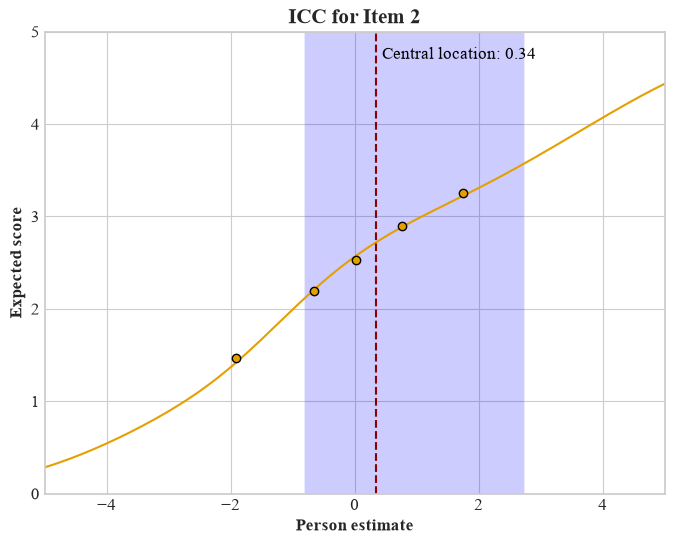

In [32]:
mfrm.icc_global('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3,
                xmin=-5, xmax=5, filename='my_mfrm_global_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

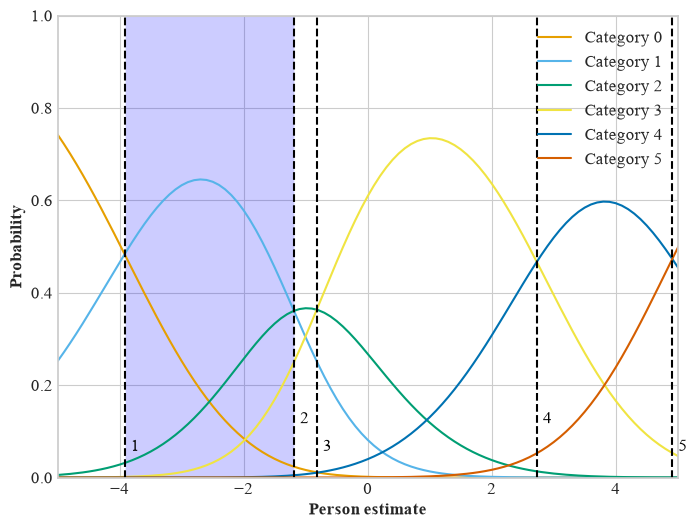

In [33]:
mfrm.crcs_global('Item_2', thresh_lines=True, cat_highlight=1, xmin=-5, xmax=5, filename='my_mfrm_global_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

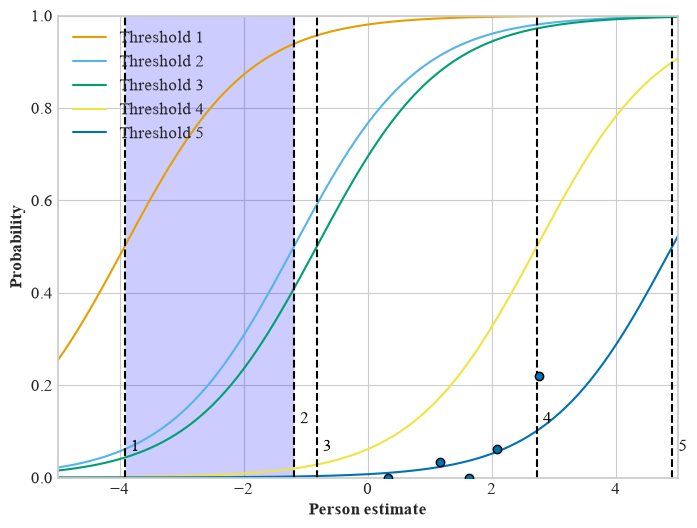

In [34]:
mfrm.threshold_ccs_global('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-5, xmax=5, filename='my_mfrm_global_threshold_ccs')

Produce an item information function curve for Item 2

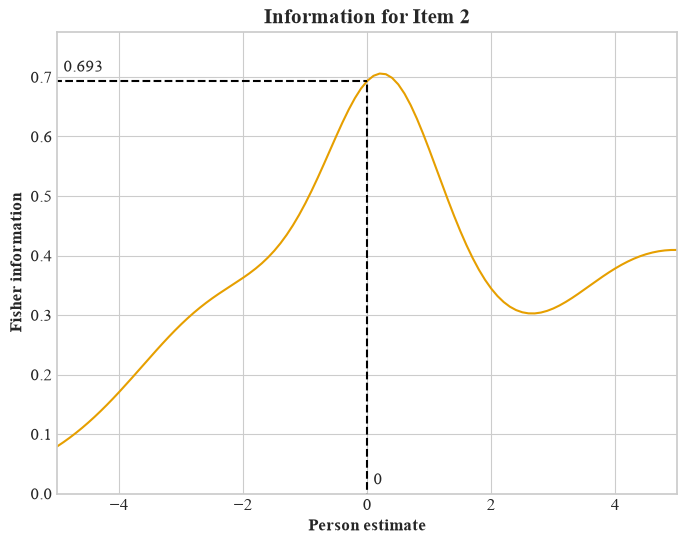

In [35]:
mfrm.iic_global('Item_2', point_info_lines=[0], point_info_labels=True, title='Information for Item 2',
                xmin=-5, xmax=5, filename='my_mfrm_global_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

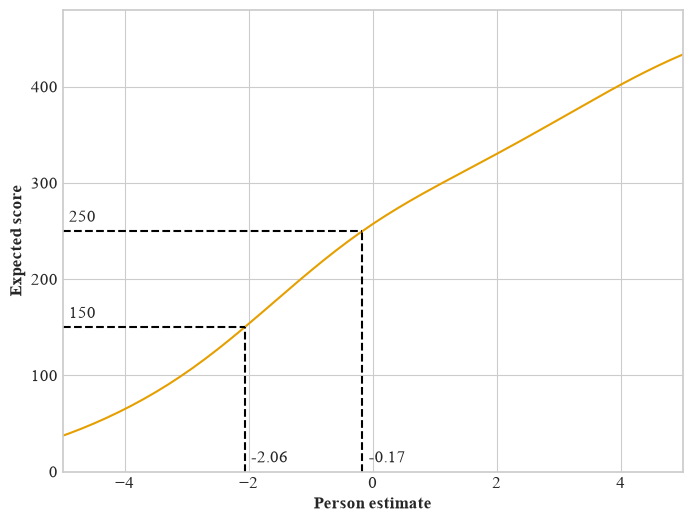

In [36]:
mfrm.tcc_global(score_lines=[150, 250], score_labels=True, filename='my_mfrm_global_tcc')

Produce a test information curve

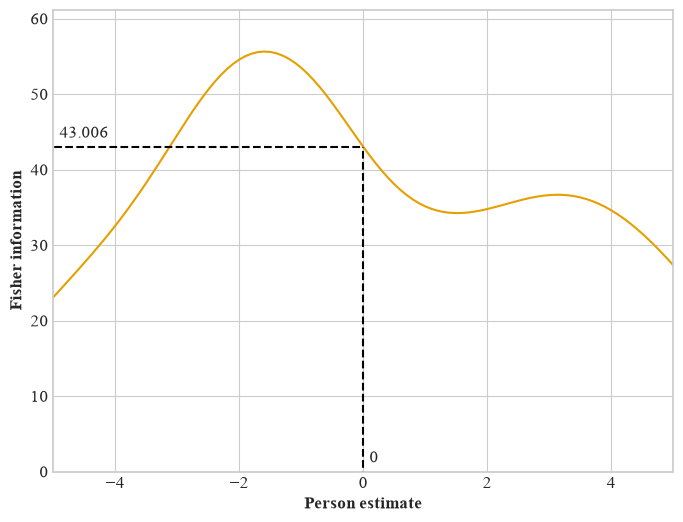

In [37]:
mfrm.test_info_global(point_info_lines=[0], point_info_labels=True, filename='my_mfrm_global_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

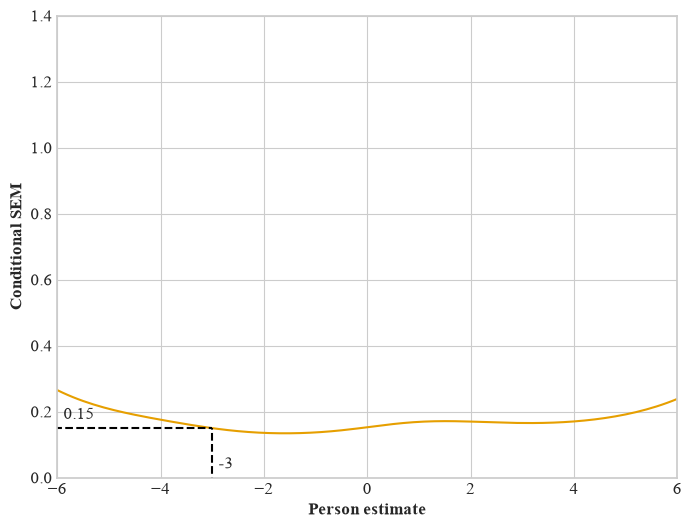

In [38]:
mfrm.test_csem_global(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-6, xmax=6, filename='my_mfrm_global_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

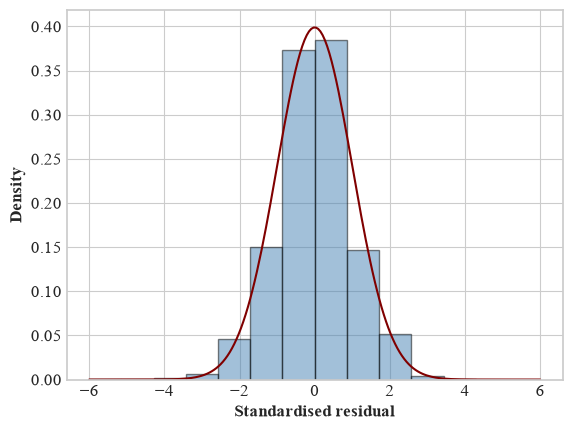

In [39]:
mfrm.std_residuals_plot_global(bin_width=0.6, normal=True, filename='my_mfrm_global_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [40]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_global_anchor(anchors)

CPU times: user 807 μs, sys: 90 μs, total: 897 μs
Wall time: 799 μs


Check the anchored rater severities against the unanchored ones.

In [41]:
rater_check = pd.DataFrame({'Unanchored': mfrm.raters_global,
                            'Anchored': mfrm.anchor_raters_global})
round(rater_check, 3)

,Unanchored,Anchored
Rater_1,1.302,0.877
Rater_2,0.143,-0.282
Rater_3,-0.214,-0.638
Rater_4,0.467,0.043
Rater_5,-0.742,-1.166
Rater_6,-0.326,-0.751
Rater_7,-0.369,-0.794
Rater_8,-0.260,-0.684


Produce a Wright map (unanchored), showing the person location distribution alongside an item strip (one row per item, divided into its own category segments at each Rasch-Andrich threshold) and a rater panel, with mean/±1SD/±2SD reference marks for persons

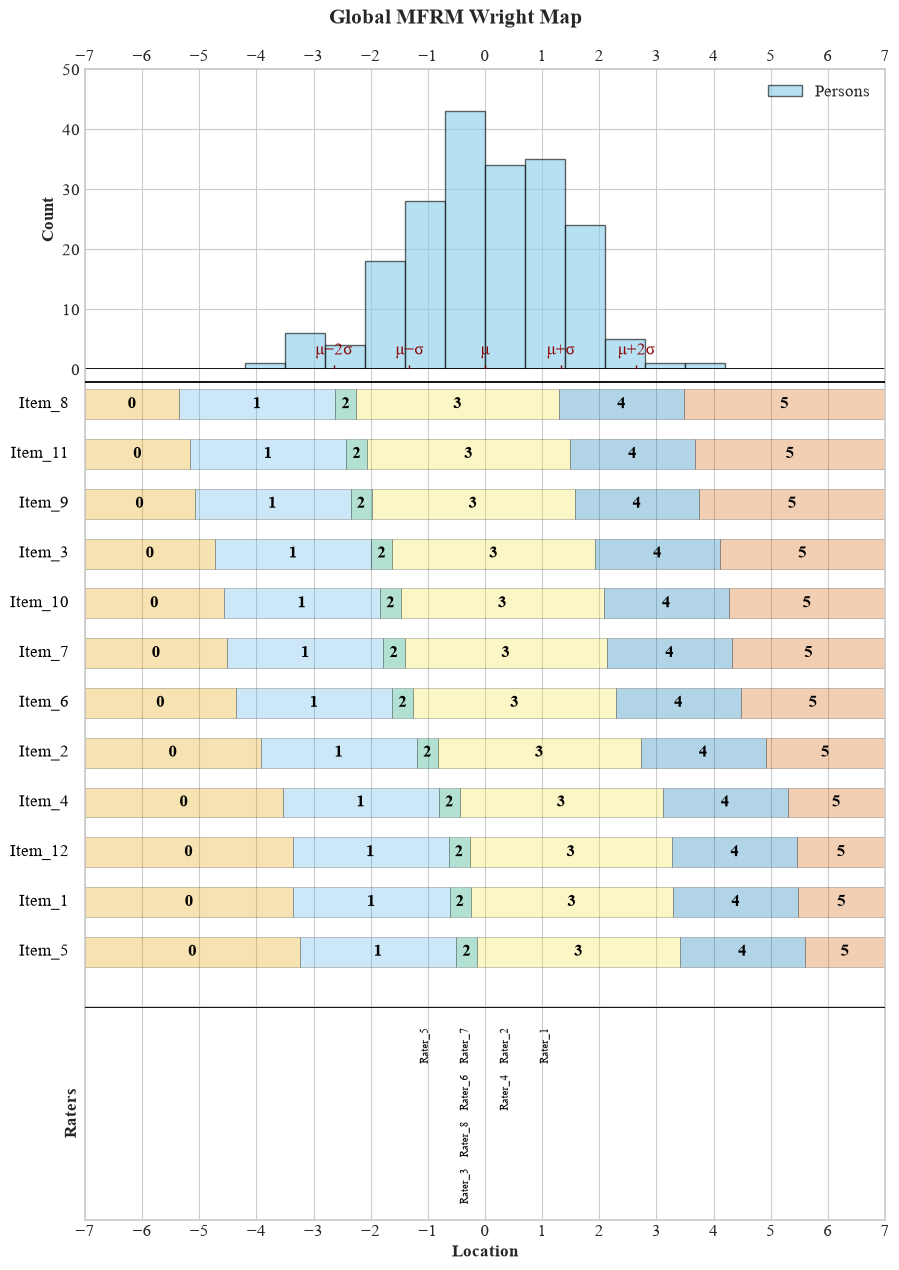

In [42]:
mfrm.wright_map_global(item_strip=True, facet_labels=True, distribution_markers=True, title='Global MFRM Wright Map', filename='my_mfrm_global_wright_map')